In [2]:
import pandas as pd
import os
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import numpy as np
import json
from extraction_tools import extraction_tools
import datetime
import re

In [2]:
# data1 = pd.read_csv('output_10.txt',header=None, delimiter=' ')
# data1 = data1[data1[1]=='average_time:'][[0, 2]].reset_index(drop=True)
# data1[0] = data1[0].apply(lambda x: x.replace('pluto_code_', '').rstrip('.pluto'))
# data1.shape

In [ ]:
dataset_path = "/home/zyj/Data0/Dataset/LOOPRAG"
pluto_path = f"{dataset_path}/pluto_code"
stdout_path = f"{dataset_path}/stdout"
poly_path = f"{dataset_path}/poly_code"

# classification = pd.read_csv("/home/zyj/Data0/Dataset/classification_output_1112.csv", index_col=0)

classification = pd.read_csv(f"{dataset_path}/classification_output_1216.csv", index_col=0)

classification['orig_file'] = classification['file_name'].apply(lambda x: x[:-2])
classification['idx'] = classification['file_name'].apply(lambda x: x[-1])

# valuable = classification
valuable = classification[(classification['loop interchange'] == 1) | (classification['loop skewing'] == 1) | (classification['loop fusion'] == 1) | (classification['loop distribution'] == 1) | (classification['loop shifting'] == 1)]


plutos = [x.split('.')[0] for x in os.listdir(pluto_path) if x.endswith('.pluto.c')]
stdouts = [x.split('.')[0] for x in os.listdir(stdout_path) if x.endswith('.stdout')]
options = list(set(plutos) & set(stdouts))

valuable.loc[:, 'file_name'] = valuable['file_name'].astype('str')

valuable

,file_name,no loop transformation,loop tiling,loop interchange,loop skewing,loop fusion,loop distribution,loop reverse,loop shifting,other loop transformation,orig_file,idx
0,2232211326_5,0,1,0,1,1,0,0,0,1,2232211326,5
1,2222331112_1,0,1,1,0,0,0,0,0,0,2222331112,1
2,2436152116_2,0,1,0,1,1,0,0,1,1,2436152116,2
4,2316331114_3,0,0,0,0,1,0,0,0,1,2316331114,3
5,4214352124_6,0,1,0,0,1,0,0,0,1,4214352124,6
...,...,...,...,...,...,...,...,...,...,...,...,...
262267,4436311122_0,0,1,1,0,1,0,0,0,1,4436311122,0
262268,3434231126_7,0,0,0,0,1,0,0,1,1,3434231126,7
262269,4226251224_3,0,1,1,0,1,0,0,0,1,4226251224,3
262272,2132152316_3,0,1,1,0,0,0,0,0,0,2132152316,3


In [17]:
valuable_new = valuable[valuable['file_name'].isin(contents.keys())]
len(valuable_new)

221678

In [18]:
df1 = valuable_new.drop_duplicates(subset='orig_file')
df0 = valuable_new[valuable_new.duplicated(subset='orig_file')]
print(len(valuable_new), len(df1), len(df0))

221678 34623 187055


In [19]:
df2 = df0.drop_duplicates(subset='orig_file')
df0 = df0[df0.duplicated(subset='orig_file')]
print(len(df2), len(df0))

34498 152557


In [20]:
df3 = df0.drop_duplicates(subset='orig_file')
df0 = df0[df0.duplicated(subset='orig_file')]
print(len(df3), len(df0))

df4 = df0.drop_duplicates(subset='orig_file')
df0 = df0[df0.duplicated(subset='orig_file')]
print(len(df4), len(df0))

33981 118576
32626 85950


In [21]:
df5 = df0.drop_duplicates(subset='orig_file')
df0 = df0[df0.duplicated(subset='orig_file')]
print(len(df5), len(df0))

df6 = df0.drop_duplicates(subset='orig_file')
df0 = df0[df0.duplicated(subset='orig_file')]
print(len(df6), len(df0))

29974 55976
25817 30159


In [4]:
def for_loop_post_process(code):
    '''
    add int for code like "for (i...)" in opt code for rag
    params:
    1. code: code part to be processed.
    example:
    post_process("for (t = 0;)")
    '''

    pattern = r'(for \()(?!int)'
    replacement = r'\1int '

    return re.sub(pattern, replacement, code)

def info_process(file):
    tool = extraction_tools()
    # print(file)
    content = defaultdict(list)
    content['filename'] = file
    content['code'] = tool.extract_codelet(f'{file}.c', poly_path)
    if not content['code']:
        return 0, "orinigal code extract failed", file

    try:
        codelet = tool.extract_codelet(f'{file}.pluto.c', pluto_path, 1)
        content['opt_code'] = for_loop_post_process(codelet)
    except ValueError as e:
        # print(file, e)
        if str(e) == "The pluto file is empty!":
            return 0, str(e), file
        else:
            return 0, 'opt codelet extract fails', file
    
    if 'i' not in content['opt_code']:
        return 0, "opt codelet content is wrong", file
    
    try:
        info = tool.get_info(f'{file}.stdout', stdout_path)
    except ValueError as e:
        # print(file, e)
        return 0, str(e), file
    except:
        return 0, 'other error', file
    
    content['info'] = info
    
    return 1, content, file

In [5]:
import multiprocessing as mp
import itertools as it

# files = list(df1.file_name) + list(df2.file_name) + list(df3.file_name) + list(df4.file_name)
# files = list(set(files) & set(options))

files = list(set(valuable.file_name) & set(options))

def pool_err_call_back(err):
    print(f'error while multiprocessing: {str(err)}.\n')

pool = mp.Pool(48)
results = pool.starmap_async(info_process, it.product(files), error_callback=pool_err_call_back)
pool.close()
pool.join()

In [6]:
contents = {}
errors = []

for res in results.get():
    if res[0]:
        content, file = res[1:]
        contents[file] = content
    else:
        errors.append(res[1:])

print(len(contents))
print(len(errors))

195086
0


In [7]:
valuable_new = valuable[valuable['file_name'].isin(contents.keys())]
available = []

for _ in range(4):
    available.extend(valuable_new.drop_duplicates(subset='orig_file').file_name.to_list())
    valuable_new = valuable_new[valuable_new.duplicated(subset='orig_file')]
    print(len(valuable_new), len(available))
    
available_contents = {key: contents[key] for key in available}
len(available_contents)

160551 34535
126508 68578
93868 101218
64034 131052


131052

In [3]:
import os
os.path.splitext(os.path.basename("./data/1/1.ab_c.aaa.c"))[0]

'1.ab_c.aaa'

In [9]:
# import os
# df_errors = pd.DataFrame(errors)
# # df_errors
# # df_errors[df_errors[0] != 'The pluto file is empty!']
# for file in df_errors[1]:
#     os.remove(f"{pluto_path}/{file}.pluto.c")

In [16]:
target_path = '/home/zyj/Data0/loop_transformation'

date = datetime.datetime.now().strftime('%m%d')
json_name = f'COLAGen_{len(available)}_{date}.json'
print(json_name)
with open(f'{target_path}/{json_name}', 'w') as fp:
    json.dump(contents, fp)

# for file in available:
#     os.system(f'rsync -r --delete {target_path}/empty/ {target_path}/poly_code_avail/')
#     os.system(f'cp {poly_path}/{file}.c {target_path}/poly_code_avail')
#     os.system(f'cp {poly_path}/{file}.h {target_path}/poly_code_avail')

# os.chdir(target_path)
# os.system(f'zip -r rag_{date}.zip ./{json_name} ./poly_code_avail')
# os.chdir(os.getcwd()) 

COLAGen_135364_1116.json


In [21]:
tttmp = pd.read_json(f"{target_path}/{json_name}")

filename                                          43163122225
code        for (int i = 2; i < PB_M; i++) {\n    for (int...
opt_code      int t1, t2, t3, t4, t5, t6, t7;\n int lb, ub...
info        [{'schedule_const': ['[0,0,0,0]', '[0,0,0,0]',...
Name: 0, dtype: object

In [22]:
tttmp.iloc[0]['info']

[{'schedule_const': ['[0,0,0,0]', '[0,0,0,0]', '[0,0,0,0]', '[0,0,0,0]'],
  'schedule_iterator': ['[1,0,0,0]', '[0,1,0,0]', '[0,0,0,0]'],
  'indexes_const_dep_read': ['[1,1]', '[1,0]'],
  'indexes_nonzero_iterator_dep_read': ['[[0,1],\n[1,0]]', '[[0,1],\n[1,0]]'],
  'indexes_nonzero_iterator_nodep_read': [],
  'indexes_const_dep_write': ['[1,1]'],
  'indexes_nonzero_iterator_dep_write': ['[[1,0],\n[0,1]]'],
  'indexes_nonzero_iterator_nodep_write': []},
 {'schedule_const': ['[0,0,0,0]', '[0,0,0,0]', '[0,0,0,1]', '[0,0,0,0]'],
  'schedule_iterator': ['[1,0,0,0]', '[0,1,0,0]', '[0,0,1,0]'],
  'indexes_const_dep_read': ['[1,1]'],
  'indexes_nonzero_iterator_dep_read': ['[[1,0],\n[0,1]]'],
  'indexes_nonzero_iterator_nodep_read': ['[[0,1],\n[1,0]]'],
  'indexes_const_dep_write': [],
  'indexes_nonzero_iterator_dep_write': [],
  'indexes_nonzero_iterator_nodep_write': []},
 {'schedule_const': ['[0,0,0,0]', '[0,0,0,0]', '[0,0,0,2]', '[0,0,0,0]'],
  'schedule_iterator': ['[1,0,0,0]', '[0,1,0,

In [ ]:
os.chdir(target_path)
os.system(f'zip -r rag_{date}.zip ./{json_name} ./poly_code_avail')

In [4]:
data3 = pd.merge(df_src, df_src, on=0, how='inner')
data3.shape

(8365, 2)

In [5]:
data3[1] = data3[0].apply(lambda x: x.split('_')[1])
data3[3] = data3[0].apply(lambda x: x.split('_')[0])
data3.head()

,0,2,1,3
0,1716548791031098492_11110,0.283113,11110,1716548791031098492
1,1716548790361865357_01110,0.023431,01110,1716548790361865357
2,1716548790418558551_11000,0.286537,11000,1716548790418558551
3,1716548790465798850_01010,0.073436,01010,1716548790465798850
4,1716548790221083653_01101,0.044349,01101,1716548790221083653


In [40]:
nonrepeat = dict()
files = set(data3[3])
for file in files:
    nonrepeat[file] = len(data3[data3[3]==file][1])

# print(nonrepeat)
   
nonrepeat_count = sorted(Counter(nonrepeat.values()).items(), key=lambda x :x[0])

len(nonrepeat)

2872

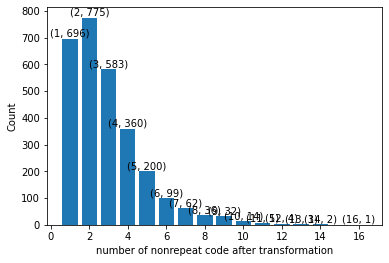

In [7]:
labels, counts = [], []
for label, count in nonrepeat_count:
    # print(label, count)
    labels.append(label)
    counts.append(count)

# Create the bar figure
plt.bar(labels, counts)

# Set labels and title
plt.xlabel('number of nonrepeat code after transformation')
plt.ylabel('Count')

# Display the figure
plt.gca().xaxis.set_major_formatter(plt.FormatStrFormatter('%d'))
for x, y in zip(labels, counts):
    plt.text(x, y, (x, y), ha='center', va='bottom')
plt.show()


In [8]:
lb = int(0.2 * len(files))
ub = int(0.3 * len(files))
# print(lb, ub)
sum = 0
for avail, count in nonrepeat_count:
    # print(avail, count, sum)
    if sum + count > ub or sum > lb:
        break
    else:
        sum += count
        
avail

2

In [38]:
availables = []
threshold = 3 # avail???
for file, value in nonrepeat.items():
    if value >= threshold:
        availables.append(file)

print(len(availables) / len(nonrepeat), f'{len(availables)}/{len(nonrepeat)}')

0.4878133704735376 1401/2872


In [10]:
test = []
for file in availables:
    X = np.array(data3[data3[3] == file][2]).reshape(-1, 1)
    model = KMeans(n_clusters=threshold, n_init='auto')
    model.fit(X)
    data3.loc[data3[3] == file, 4] = model.fit_predict(X)


/home/zyj/.local/lib/python3.8/site-packages/sklearn/base.py:1152: ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (3). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/home/zyj/.local/lib/python3.8/site-packages/sklearn/base.py:1152: ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (3). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/home/zyj/.local/lib/python3.8/site-packages/sklearn/base.py:1152: ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (3). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/home/zyj/.local/lib/python3.8/site-packages/sklearn/base.py:1152: ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (3). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/home/zyj/.local/lib/python3.8/site-

In [11]:
data4 = pd.merge(data3, pd.DataFrame(availables, columns=[3]), on = 3, how = 'inner')
data4.head()

,0,2,1,3,4
0,1716548791031098492_11110,0.283113,11110,1716548791031098492,0.0
1,1716548791031098492_00101,0.508532,00101,1716548791031098492,1.0
2,1716548791031098492_11000,0.253624,11000,1716548791031098492,0.0
3,1716548791031098492_11001,0.476970,11001,1716548791031098492,2.0
4,1716548790361865357_01110,0.023431,01110,1716548790361865357,0.0


In [22]:
data4.loc[data4[3] == '1716548790748059963']

,0,2,1,3,4
3857,1716548790748059963_11101,0.000045,11101,1716548790748059963,1.0
3858,1716548790748059963_00100,0.000045,00100,1716548790748059963,1.0
3859,1716548790748059963_01012,0.000045,01012,1716548790748059963,1.0
3860,1716548790748059963_11010,0.000051,11010,1716548790748059963,0.0


In [27]:
final = defaultdict(list)
for file in availables:
    for i in range(threshold):
        try:
            final[file].append(data4.iloc[data4[(data4[3] == file) & (data4[4] == i)][2].idxmin(), [1,2]])
            final[file] = sorted(final[file], key=lambda x:x[2])
        except:
            del final[file]
            print(file, i)
            break
            
    
        
final

1716548790748059963 2
1716548790257462094 2
1716548790259571627 2


In [37]:
len(final)

1401

In [36]:
tool = extraction_tools()
os.system('rsync -r --delete empty/ brio_json/')
zip_name = 'brio_pluto_code_0524_3.zip'

for file in availables:
    brio = defaultdict(list)
    brio['code'].append(tool.extract_codelet(f'{file}.c' ,poly_path))
    for time, opts in final[file]:
        brio['candidates'].append([[tool.extract_codelet(f'{file}_{opts}.pluto.c', pluto_path, 1)], time])
     
    with open(f'./brio_json/brio_{file}_{threshold}.json', 'w') as fp:
        json.dump(brio, fp)
        
os.system(f'zip -r {zip_name} ./brio_json')

  adding: brio_json/ (stored 0%)
  adding: brio_json/brio_1716548790525911324_3.json (deflated 74%)
  adding: brio_json/brio_1716548791059450135_3.json (deflated 71%)
  adding: brio_json/brio_1716548790355115467_3.json (deflated 79%)
  adding: brio_json/brio_1716548790450568044_3.json (deflated 66%)
  adding: brio_json/brio_1716548790498947581_3.json (deflated 79%)
  adding: brio_json/brio_1716548791315031365_3.json (deflated 76%)
  adding: brio_json/brio_1716548790396328237_3.json (deflated 80%)
  adding: brio_json/brio_1716548790188761956_3.json (deflated 85%)
  adding: brio_json/brio_1716548790723797192_3.json (deflated 65%)
  adding: brio_json/brio_1716548791024336329_3.json (deflated 71%)
  adding: brio_json/brio_1716548790360011052_3.json (deflated 70%)
  adding: brio_json/brio_1716548791129374681_3.json (deflated 77%)
  adding: brio_json/brio_1716548790445832644_3.json (deflated 85%)
  adding: brio_json/brio_1716548791256554958_3.json (deflated 80%)
  adding: brio_json/brio_1716

0

In [104]:
data4.columns = ['file_name', 'time', 'option', 'original_file', 'class']
data4.head()

,file_name,time,option,original_file,class
0,1716548790361865357_01110,0.023431,01110,1716548790361865357,1.0
1,1716548790361865357_10002,0.458264,10002,1716548790361865357,0.0
2,1716548790361865357_11011,0.021205,11011,1716548790361865357,4.0
3,1716548790361865357_11110,0.018548,11110,1716548790361865357,3.0
4,1716548790361865357_01100,0.040440,01100,1716548790361865357,2.0


In [105]:
data4.to_csv('orig_0524.csv', columns=['file_name', 'time', 'option', 'original_file'], index=None)

In [27]:
import pandas as pd

test = pd.read_csv('./classification_output.csv', index_col=0)
test['filename'] = test['file_name'].apply(lambda x: x.split('_')[0])
test['option'] = test['file_name'].apply(lambda x: x.split('_')[1])
del test['file_name']
test.head()

,no loop transformation,loop tiling,loop interchange,loop skewing,loop fusion,loop distribution,loop reverse,loop shifting,other loop transformation,filename,option
0,0,1,0,0,0,0,0,0,0,s423,1001
1,0,0,0,0,0,0,0,0,1,s252,0101
2,1,0,0,0,0,0,0,0,0,s241,1100
3,0,1,0,0,0,0,1,0,0,s1112,1012
4,0,1,0,1,0,0,0,0,0,s256,1110


In [28]:
test1 = test.groupby(['filename']).sum()
test1.head()

,no loop transformation,loop tiling,loop interchange,loop skewing,loop fusion,loop distribution,loop reverse,loop shifting,other loop transformation,option
filename,,,,,,,,,,
s000,12,12,0,0,0,0,0,0,0,1000010010120000011010100112001110021110010211...
s1112,0,12,0,0,0,0,24,0,0,1012001211121002000210110010011211100111101000...
s1115,12,12,0,0,0,0,0,0,0,0100001111001011101210010111001211100110010110...
s1119,6,12,12,0,0,0,0,0,0,1110100211110112000201101001101200121000010200...
s112,24,0,0,0,0,0,0,0,0,0011110210100010011010000111000210110000010111...


In [45]:
b = test1[(test1['loop interchange'] == 0) & (test1['loop skewing'] == 0) & (test1['loop fusion'] == 0) & (test1['loop distribution'] == 0) & (test1['loop shifting'] == 0)].index

In [49]:
import csv
with open('./tsvc_not_suitable.txt', 'w') as f:
    writer = csv.writer(f)
    writer.writerow(list(a))
    writer.writerow(list(set(b) - set(a)))